# Real-Time Driving Perception Inference — Runner Notebook

Run this notebook on **Google Colab with a GPU runtime** (Runtime → Change runtime type → T4 GPU).

Each phase has its own section. Run sections top-to-bottom in a single session.

## 0. Configuration

Edit these variables before running anything else.

In [1]:
# ── Fill in your values ──────────────────────────────────────────────────────
REPO_URL         = 'https://github.com/khushalrs/Inference_pipeline_eval.git'
REPO_DIR         = 'real-time-driving-inference-optimizer'   # folder cloned into /content
DRIVE_VIDEO_PATH = '/content/drive/MyDrive/Colab Notebooks/car_clip.mp4'         # path to video on your Drive
# ─────────────────────────────────────────────────────────────────────────────

import os
WORKSPACE = f'/content/{REPO_DIR}'
print(f'Workspace : {WORKSPACE}')
print(f'Repo URL  : {REPO_URL}')

Workspace : /content/real-time-driving-inference-optimizer
Repo URL  : https://github.com/khushalrs/Inference_pipeline_eval.git


## 1. Setup — Mount Drive, Clone Repo, Install Dependencies

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

if os.path.exists(WORKSPACE):
    print('Repo already cloned — pulling latest changes...')
    !git -C {WORKSPACE} pull
else:
    !git clone {REPO_URL} {WORKSPACE}

%cd {WORKSPACE}
!pwd

Cloning into '/content/real-time-driving-inference-optimizer'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 76 (delta 28), reused 72 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 40.61 KiB | 10.15 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/real-time-driving-inference-optimizer
/content/real-time-driving-inference-optimizer


In [4]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.3/220.3 MB 6.0 MB/s eta 0:00:00


## 2. Environment Check

In [5]:
import torch

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'CUDA version    : {torch.version.cuda}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : Tesla T4
CUDA version    : 12.8
VRAM            : 15.6 GB


## 3. Copy Video from Drive

In [6]:
import shutil, os

dest = 'data/clip.mp4'
os.makedirs('data', exist_ok=True)

if not os.path.exists(dest):
    print(f'Copying {DRIVE_VIDEO_PATH} → {dest} ...')
    shutil.copy(DRIVE_VIDEO_PATH, dest)
    print('Done.')
else:
    print(f'{dest} already present.')

size_mb = os.path.getsize(dest) / 1e6
print(f'File size: {size_mb:.1f} MB')

Copying /content/drive/MyDrive/Colab Notebooks/car_clip.mp4 → data/clip.mp4 ...
Done.
File size: 551.5 MB


## Phase 1 — PyTorch Baseline Inference

Runs YOLO11n on every frame. Records per-frame latency for each pipeline stage:
read → preprocess → inference → postprocess → draw+write.

Outputs:
- `results/pytorch_output.mp4` — annotated video
- `results/pytorch_raw_timings.csv` — per-frame timings

In [7]:
!python3 scripts/run_pytorch_video.py \
    --video data/clip.mp4 \
    --results results/pytorch_raw_timings.csv \
    --model yolo11n.pt \
    --input-size 640 \
    --conf 0.25 \
    --iou 0.45 \
    --warmup 10 \
    --device cuda

Device      : cuda
Loading     : yolo11n.pt
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU         : Tesla T4
CUDA version: 12.8
Warming up (10 iterations) ...

Video       : data/clip.mp4
Resolution  : 3840x2160  |  FPS: 30.0  |  Frames: 2516
Output video: results/pytorch_output.mp4

  Frame    1/2516  total= 657.0ms  inf= 12.1ms  pre= 31.8ms  post=265.9ms
  Frame   50/2516  total= 155.1ms  inf= 17.9ms  pre=  6.1ms  post=  2.5ms
  Frame  100/2516  total= 259.9ms  inf= 36.6ms  pre= 11.6ms  post=  5.8ms
  Frame  150/2516  total= 133.5ms  inf= 16.9ms  pre=  5.5ms  post=  2.4ms
  Frame  200/2516  total= 270.3ms  inf= 42.8ms  pre=  9.7ms  post=  6.7ms
  Frame  250/2516  total= 133.1ms  inf= 17.0ms  pre=  5.6ms  post=  2.4ms
  

### Phase 1 Results Preview

In [8]:
import pandas as pd
import sys
sys.path.insert(0, '.')
from src.metrics import compute_stats, fps_from_mean_ms

df = pd.read_csv('results/pytorch_raw_timings.csv')
print(f'Frames recorded: {len(df)}')
print()

stages = ['read_ms', 'preprocess_ms', 'inference_ms', 'postprocess_ms', 'draw_write_ms', 'total_ms']
summary = []
for col in stages:
    s = compute_stats(df[col].tolist())
    summary.append({
        'stage':   col.replace('_ms', ''),
        'mean_ms': round(s['mean_ms'], 2),
        'p50_ms':  round(s['p50_ms'],  2),
        'p90_ms':  round(s['p90_ms'],  2),
        'p99_ms':  round(s['p99_ms'],  2),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print()
total_mean = df['total_ms'].mean()
print(f'End-to-end FPS: {fps_from_mean_ms(total_mean):.1f}')

Frames recorded: 2516

      stage  mean_ms  p50_ms  p90_ms  p99_ms
       read    14.44   12.71   20.65   26.93
 preprocess     6.57    5.60   11.19   13.05
  inference    20.20   17.39   31.69   40.84
postprocess     2.76    2.37    4.21    6.86
 draw_write   114.00  104.47  165.39  201.83
      total   157.97  142.70  232.40  268.57

End-to-end FPS: 6.3


### Download Results

Download the CSV and annotated video before ending the session.

In [9]:
from google.colab import files

files.download('results/pytorch_raw_timings.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Phase 2 — Benchmarking

Aggregates the Phase 1 raw timings into a summary CSV with mean / p50 / p90 / p99
per pipeline stage, then generates four charts:
- `plots/pipeline_breakdown.png` — stacked bar of mean stage times
- `plots/latency_percentiles.png` — p50 / p90 / p99 per stage
- `plots/fps_comparison.png` — FPS bar chart
- `plots/latency_timeline.png` — per-frame total latency over time

Output: `results/pytorch_baseline.csv`

In [10]:
!python3 scripts/benchmark.py \
    --results results/pytorch_raw_timings.csv \
    --output  results/pytorch_baseline.csv \
    --runtime pytorch

Runtime : pytorch
Source  : results/pytorch_raw_timings.csv  (2516 frames)

Stage                Mean     Std      p50      p90      p99      Max
─────────────────────────────────────────────────────────────────────
read                14.44    6.48    12.71    20.65    26.93   237.77
preprocess           6.57    2.23     5.60    11.19    13.05    31.79
inference           20.20    6.20    17.39    31.69    40.84    49.40
postprocess          2.76    5.72     2.37     4.21     6.86   265.85
draw_write         114.00   29.02   104.47   165.39   201.83   233.24
total              157.97   40.37   142.71   232.40   268.57   656.99

End-to-end FPS (mean total): 6.3
End-to-end FPS (p50  total): 7.0

Saved summary → results/pytorch_baseline.csv


In [11]:
!python3 scripts/plot_results.py \
    --baselines results/pytorch_baseline.csv \
    --raw       results/pytorch_raw_timings.csv \
    --labels    pytorch \
    --output-dir plots/

Saved → plots/pipeline_breakdown.png
Saved → plots/fps_comparison.png
Saved → plots/latency_percentiles.png
Saved → plots/latency_timeline.png

All charts written to plots/


### Phase 2 — Inline Chart Preview

── pipeline_breakdown ──


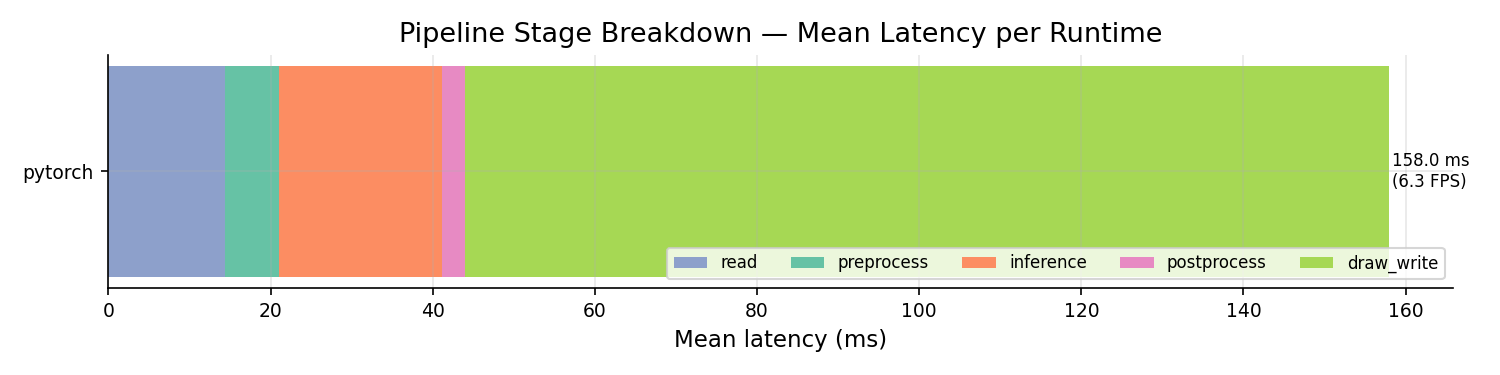

── latency_percentiles ──


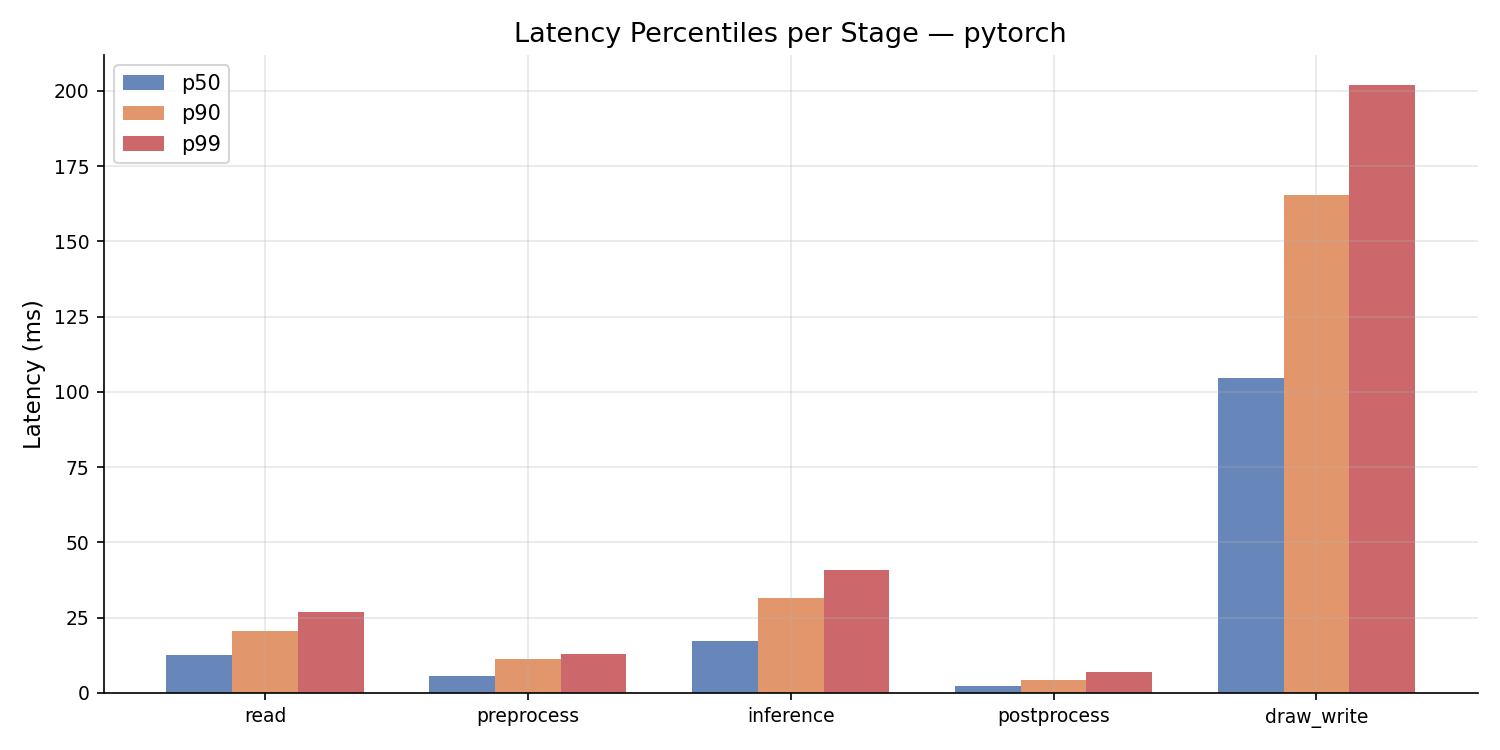

── fps_comparison ──


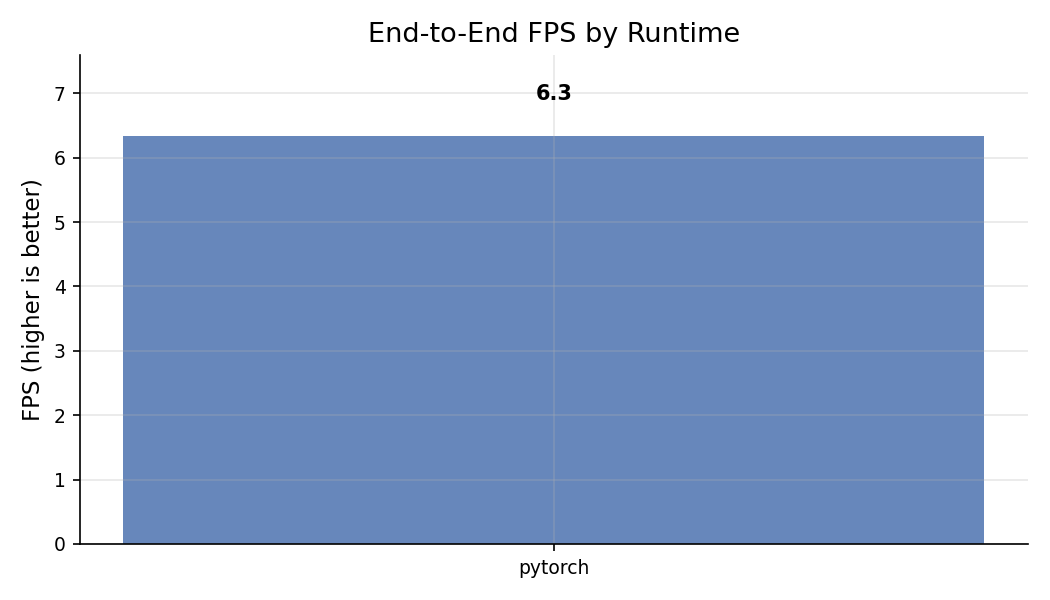

── latency_timeline ──


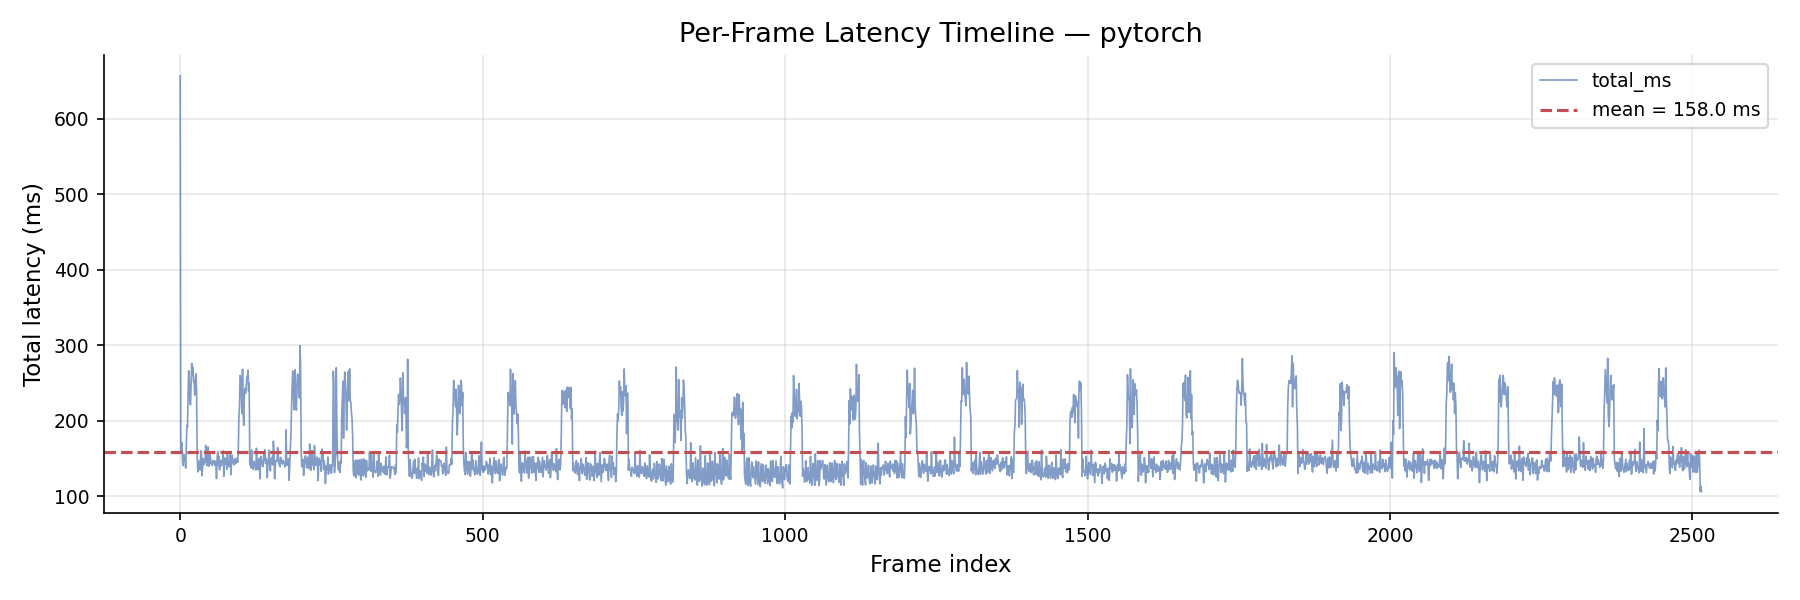

In [12]:
from IPython.display import Image, display

for chart in ['pipeline_breakdown', 'latency_percentiles', 'fps_comparison', 'latency_timeline']:
    path = f'plots/{chart}.png'
    print(f'── {chart} ──')
    display(Image(filename=path))

### Phase 2 — Download Results

In [13]:
from google.colab import files

files.download('results/pytorch_baseline.csv')
for chart in ['pipeline_breakdown', 'latency_percentiles', 'fps_comparison', 'latency_timeline']:
    files.download(f'plots/{chart}.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Phase 3 — ONNX Export and Validation

Exports YOLO11n to ONNX, then runs ORT inference on the full video with
identical 5-stage timing. Also validates output consistency vs PyTorch
(raw diff, detection count match rate, box/confidence drift).

Outputs:
- `models/yolo11n.onnx` — exported ONNX model
- `results/onnx_output.mp4` — annotated video
- `results/onnx_raw_timings.csv` — per-frame timings
- `results/onnx_benchmark.csv` — summary stats

In [14]:
!pip install onnxruntime-gpu==1.20.1 --force-reinstall -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 46.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
google-cl

In [15]:
!python3 scripts/export_onnx.py \
    --model      yolo11n.pt \
    --output     models/yolo11n.onnx \
    --input-size 640 \
    --validate \
    --video      data/clip.mp4 \
    --val-frames 20 \
    --device     cuda

Exporting yolo11n.pt → ONNX (imgsz=640) ...
Ultralytics 8.4.76 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 209ms
Prepared 2 packages in 36ms
Installed 2 packages in 6ms
 + colorama==0.4.6
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 3.1s, saved as 'yolo11n

In [16]:
!python3 scripts/run_onnx_video.py \
    --video        data/clip.mp4 \
    --onnx-model   models/yolo11n.onnx \
    --results      results/onnx_raw_timings.csv \
    --input-size   640 \
    --conf         0.25 \
    --iou          0.45 \
    --warmup       10 \
    --device       cuda

Loading ONNX model: models/yolo11n.onnx
2026-06-24 22:28:35.723258298 [W:onnxruntime:, transformer_memcpy.cc:74 ApplyImpl] 4 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
ORT providers : ['CUDAExecutionProvider', 'CPUExecutionProvider']
GPU : Tesla T4
Warming up (10 iterations) ...

Video      : data/clip.mp4
Resolution : 3840x2160  |  FPS: 30.0  |  Frames: 2516
Output     : results/onnx_output.mp4

  Frame    1/2516  total= 345.7ms  inf= 12.5ms  pre=  6.2ms  post=  3.2ms
  Frame   50/2516  total= 146.0ms  inf= 12.9ms  pre=  4.4ms  post=  3.1ms
  Frame  100/2516  total= 143.6ms  inf= 14.1ms  pre=  4.6ms  post=  6.8ms
  Frame  150/2516  total= 136.1ms  inf= 13.3ms  pre=  4.5ms  post=  2.9ms
  Frame  200/2516  total= 182.3ms  inf= 15.3ms  pre=  5.6ms  post=  3.9ms
  Frame  250/2516  total= 135.2

In [17]:
!python3 scripts/benchmark.py \
    --results results/onnx_raw_timings.csv \
    --output  results/onnx_benchmark.csv \
    --runtime onnx

Runtime : onnx
Source  : results/onnx_raw_timings.csv  (2516 frames)

Stage                Mean     Std      p50      p90      p99      Max
─────────────────────────────────────────────────────────────────────
read                15.28    6.48    13.04    21.62    32.22   217.67
preprocess           5.32    2.00     4.52     8.29    12.20    32.30
inference           14.80    3.12    13.79    19.30    25.44    48.30
postprocess          3.44    1.13     3.08     4.98     7.55    11.67
draw_write         121.71   35.79   109.09   175.46   222.04   493.09
total              160.55   43.88   143.64   229.71   282.34   608.42

End-to-end FPS (mean total): 6.2
End-to-end FPS (p50  total): 7.0

Saved summary → results/onnx_benchmark.csv


### Phase 3 — PyTorch vs ONNX Comparison Charts

In [18]:
!python3 scripts/plot_results.py \
    --baselines results/pytorch_baseline.csv results/onnx_benchmark.csv \
    --labels    pytorch onnx \
    --output-dir plots/

Saved → plots/pipeline_breakdown.png
Saved → plots/fps_comparison.png
Saved → plots/latency_percentiles.png

All charts written to plots/


── pipeline_breakdown ──


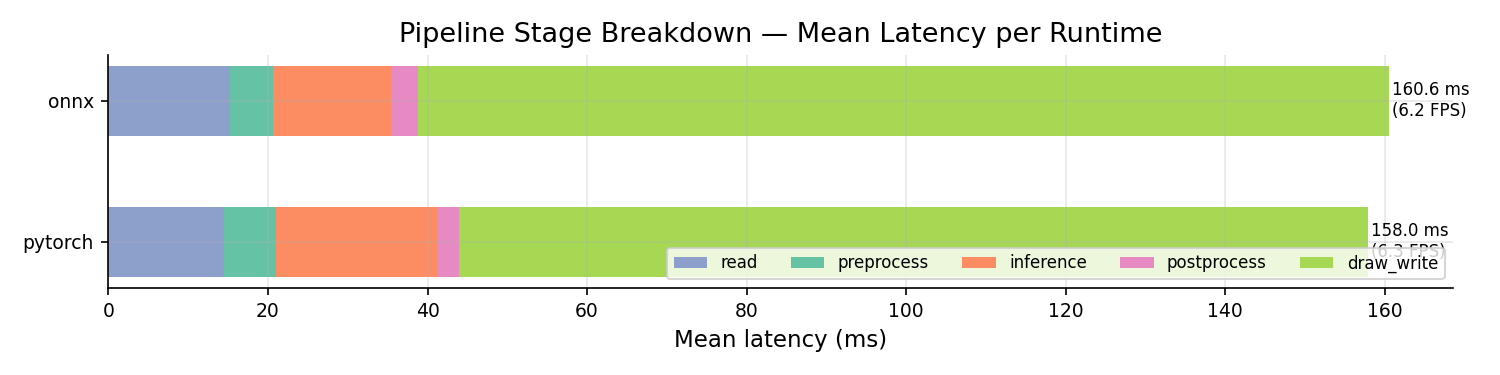

── latency_percentiles ──


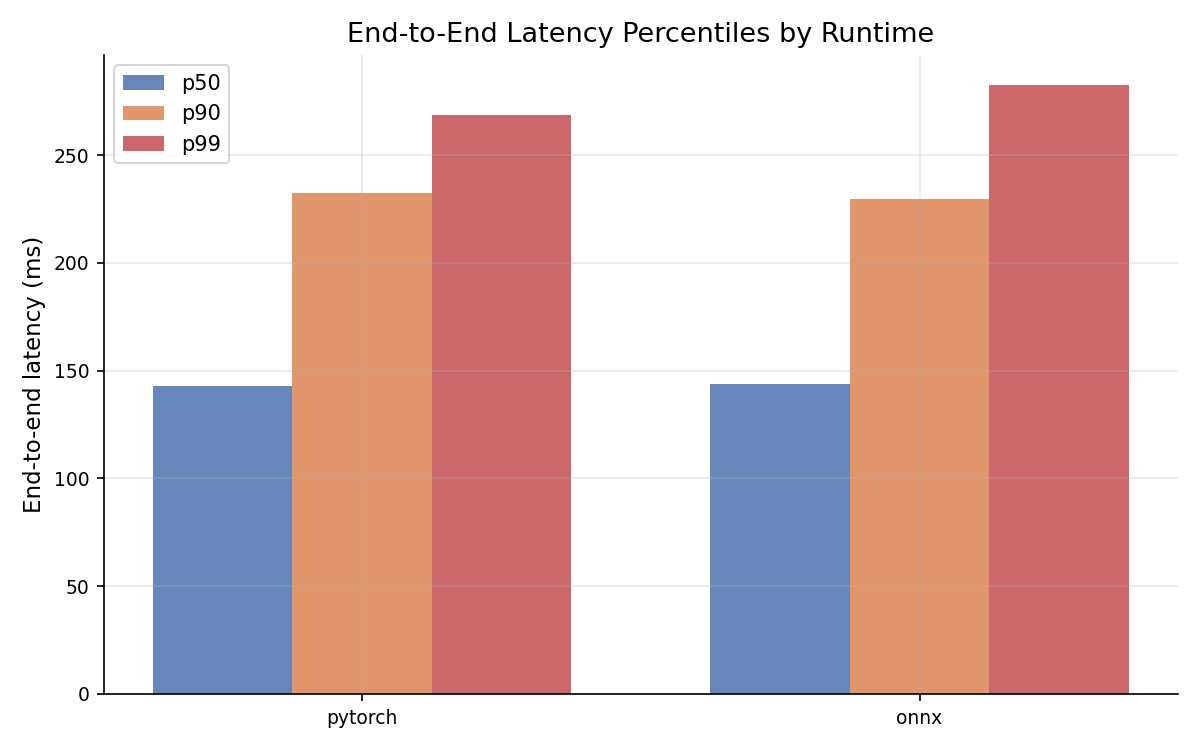

── fps_comparison ──


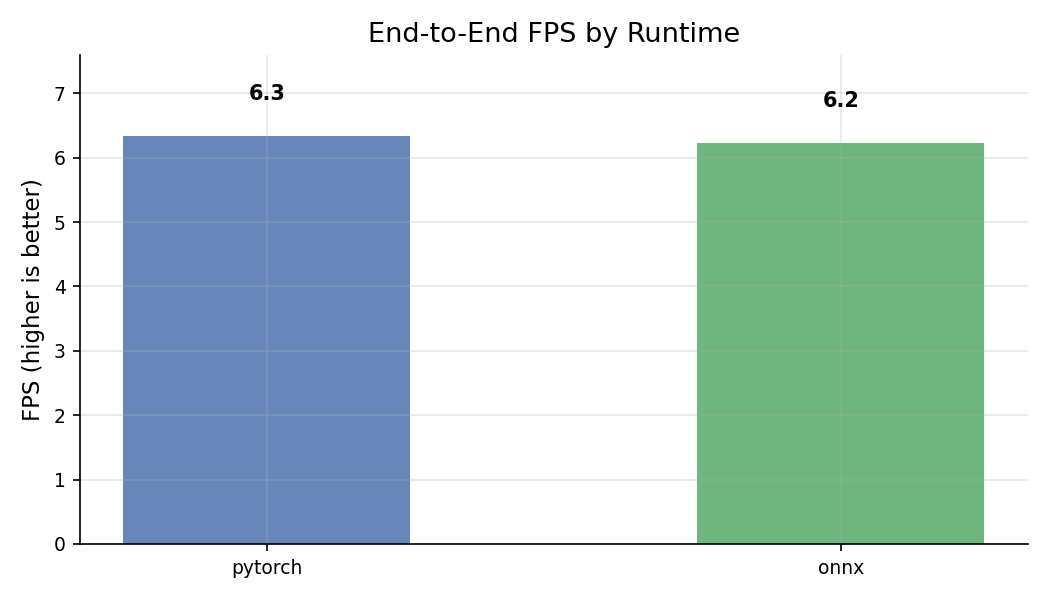

In [19]:
from IPython.display import Image, display

for chart in ['pipeline_breakdown', 'latency_percentiles', 'fps_comparison']:
    print(f'── {chart} ──')
    display(Image(filename=f'plots/{chart}.png'))

### Phase 3 — Download Results

In [20]:
from google.colab import files

files.download('results/onnx_raw_timings.csv')
files.download('results/onnx_benchmark.csv')
for chart in ['pipeline_breakdown', 'latency_percentiles', 'fps_comparison']:
    files.download(f'plots/{chart}.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Phase 4 — TensorRT Optimization

Builds FP32 and FP16 TRT engines from the ONNX model, then runs both on the
full video with the same 5-stage timing. Engine build is hardware-specific and
**must be rebuilt at the start of every new Colab session**.

Build times on T4:  FP32 ≈ 2–5 min  /  FP16 ≈ 3–7 min

Outputs:
- `models/yolo11n_fp32.engine` / `models/yolo11n_fp16.engine`
- `results/trt_fp32_raw_timings.csv` / `results/trt_fp16_raw_timings.csv`
- `results/trt_fp32_benchmark.csv`  / `results/trt_fp16_benchmark.csv`

### Phase 4 — Build Engines (FP32 + FP16)

In [21]:
!pip install tensorrt-cu12 --extra-index-url https://pypi.nvidia.com -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 GB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 1.1 MB/s eta 0:00:00


In [22]:
!python3 scripts/build_tensorrt_engine.py \
    --onnx         models/yolo11n.onnx \
    --output-dir   models/ \
    --fp32 --fp16 \
    --workspace-gb 2


── Building FP32 engine ────────────────────────────────
TRT version  : 11.1.0.106
ONNX source  : models/yolo11n.onnx
Output       : models/yolo11n_fp32.engine
Workspace    : 2 GB
(First build may take several minutes — subsequent builds use cache)

[DONE] FP32 engine  →  models/yolo11n_fp32.engine  (13.7 MB)  in 70s

── Building FP16 engine ────────────────────────────────
TRT version  : 11.1.0.106
ONNX source  : models/yolo11n.onnx
Output       : models/yolo11n_fp16.engine
Workspace    : 2 GB
(First build may take several minutes — subsequent builds use cache)

[INFO] TRT 11+: BuilderFlag.FP16 removed; TRT will auto-use FP16 Tensor Cores on supported hardware.
[DONE] FP16 engine  →  models/yolo11n_fp16.engine  (13.9 MB)  in 57s

Engines ready:
  models/yolo11n_fp32.engine  (13.7 MB)
  models/yolo11n_fp16.engine  (13.9 MB)


### Phase 4 — Run FP32 Inference

In [23]:
!python3 scripts/run_tensorrt_video.py \
    --video        data/clip.mp4 \
    --engine       models/yolo11n_fp32.engine \
    --results      results/trt_fp32_raw_timings.csv \
    --input-size   640 \
    --conf         0.25 \
    --iou          0.45 \
    --warmup       10

Loading engine : models/yolo11n_fp32.engine
GPU            : Tesla T4
Input  shape   : (1, 3, 640, 640)
Output shape   : (1, 84, 8400)
Output dtype   : torch.float32

Warming up (10 iterations) ...
[06/24/2026-22:40:39] [TRT] [W] Using default stream in enqueueV3() may lead to performance issues due to additional calls to cudaStreamSynchronize() by TensorRT to ensure correct synchronization. Please use non-default stream instead.
Warmup complete.

Video   : data/clip.mp4
Frames  : 2516  |  3840x2160  |  30.0 FPS
Output  : results/trt_fp32_output.mp4

  Frame    1/2516  total= 794.8ms  inf=  8.3ms  pre= 22.6ms  post=423.9ms
  Frame   50/2516  total= 143.7ms  inf=  8.2ms  pre=  8.2ms  post=  2.7ms
  Frame  100/2516  total= 137.0ms  inf=  8.3ms  pre=  4.3ms  post=  3.1ms
  Frame  150/2516  total= 126.5ms  inf=  8.3ms  pre=  4.3ms  post=  2.8ms
  Frame  200/2516  total= 648.4ms  inf= 14.1ms  pre= 16.5ms  post=  8.2ms
  Frame  250/2516  total= 125.5ms  inf=  8.3ms  pre=  4.2ms  post=  2.7ms

In [24]:
!python3 scripts/benchmark.py \
    --results results/trt_fp32_raw_timings.csv \
    --output  results/trt_fp32_benchmark.csv \
    --runtime trt-fp32

Runtime : trt-fp32
Source  : results/trt_fp32_raw_timings.csv  (2516 frames)

Stage                Mean     Std      p50      p90      p99      Max
─────────────────────────────────────────────────────────────────────
read                15.14    6.78    13.16    21.62    36.25   225.83
preprocess           5.12    1.78     4.33     8.12    10.84    22.61
inference            8.77    1.19     8.31    10.65    12.83    22.89
postprocess          3.22    9.62     2.71     4.52     7.19   423.88
draw_write         118.21   36.66   106.48   171.43   217.17   568.38
total              150.47   45.55   134.98   216.80   262.52   794.84

End-to-end FPS (mean total): 6.6
End-to-end FPS (p50  total): 7.4

Saved summary → results/trt_fp32_benchmark.csv


### Phase 4 — Run FP16 Inference

In [25]:
!python3 scripts/run_tensorrt_video.py \
    --video        data/clip.mp4 \
    --engine       models/yolo11n_fp16.engine \
    --results      results/trt_fp16_raw_timings.csv \
    --input-size   640 \
    --conf         0.25 \
    --iou          0.45 \
    --warmup       10

Loading engine : models/yolo11n_fp16.engine
GPU            : Tesla T4
Input  shape   : (1, 3, 640, 640)
Output shape   : (1, 84, 8400)
Output dtype   : torch.float32

Warming up (10 iterations) ...
[06/24/2026-22:47:07] [TRT] [W] Using default stream in enqueueV3() may lead to performance issues due to additional calls to cudaStreamSynchronize() by TensorRT to ensure correct synchronization. Please use non-default stream instead.
Warmup complete.

Video   : data/clip.mp4
Frames  : 2516  |  3840x2160  |  30.0 FPS
Output  : results/trt_fp16_output.mp4

  Frame    1/2516  total= 751.3ms  inf=  8.2ms  pre=  5.3ms  post=208.0ms
  Frame   50/2516  total= 141.8ms  inf=  8.3ms  pre=  4.3ms  post=  2.7ms
  Frame  100/2516  total= 252.5ms  inf=  8.1ms  pre=  4.2ms  post=  2.5ms
  Frame  150/2516  total= 128.4ms  inf=  8.2ms  pre=  4.3ms  post=  2.8ms
  Frame  200/2516  total= 157.6ms  inf=  8.2ms  pre=  4.4ms  post=  2.7ms
  Frame  250/2516  total= 131.0ms  inf=  8.2ms  pre=  4.3ms  post=  2.7ms

In [26]:
!python3 scripts/benchmark.py \
    --results results/trt_fp16_raw_timings.csv \
    --output  results/trt_fp16_benchmark.csv \
    --runtime trt-fp16

Runtime : trt-fp16
Source  : results/trt_fp16_raw_timings.csv  (2516 frames)

Stage                Mean     Std      p50      p90      p99      Max
─────────────────────────────────────────────────────────────────────
read                15.07    9.66    13.03    21.31    34.80   381.60
preprocess           5.07    1.61     4.39     8.15    10.46    24.04
inference            8.72    1.12     8.28    10.60    12.92    24.13
postprocess          3.13    4.37     2.81     4.59     7.26   208.03
draw_write         117.15   30.36   106.50   170.04   206.49   235.21
total              149.15   38.34   135.12   214.34   254.39   751.34

End-to-end FPS (mean total): 6.7
End-to-end FPS (p50  total): 7.4

Saved summary → results/trt_fp16_benchmark.csv


### Phase 4 — Full 4-Runtime Comparison Charts

Regenerates all comparison charts with all four runtimes side by side.

In [27]:
!python3 scripts/plot_results.py \
    --baselines results/pytorch_baseline.csv \
                results/onnx_benchmark.csv \
                results/trt_fp32_benchmark.csv \
                results/trt_fp16_benchmark.csv \
    --labels    pytorch onnx trt-fp32 trt-fp16 \
    --output-dir plots/

Saved → plots/pipeline_breakdown.png
Saved → plots/fps_comparison.png
Saved → plots/latency_percentiles.png

All charts written to plots/


── pipeline_breakdown ──


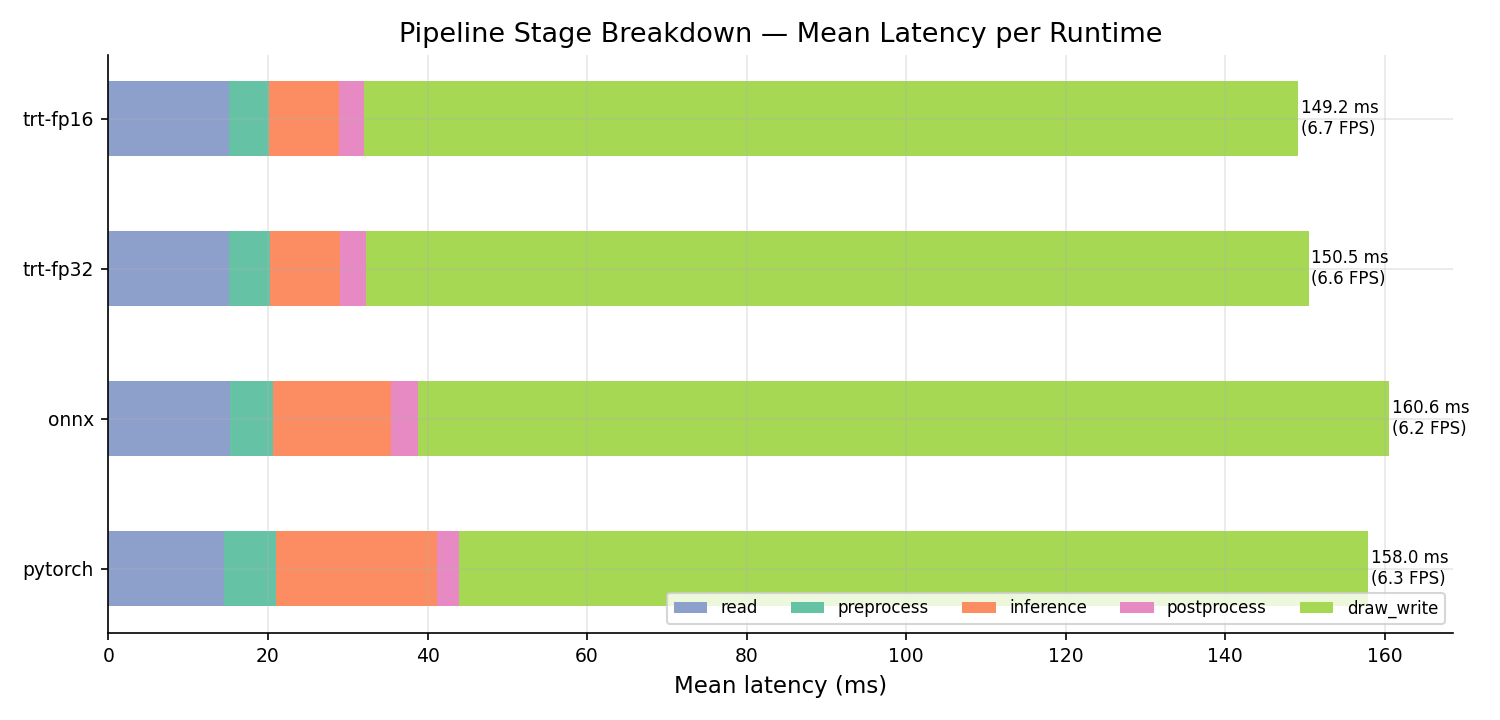

── latency_percentiles ──


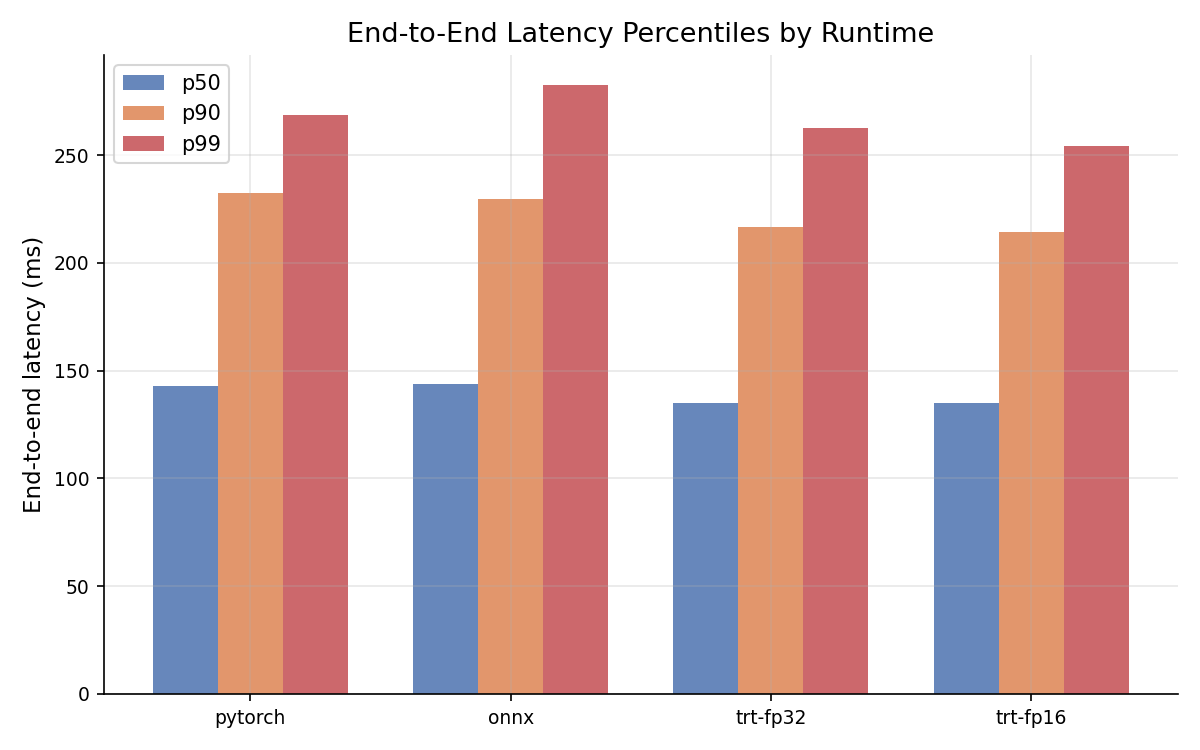

── fps_comparison ──


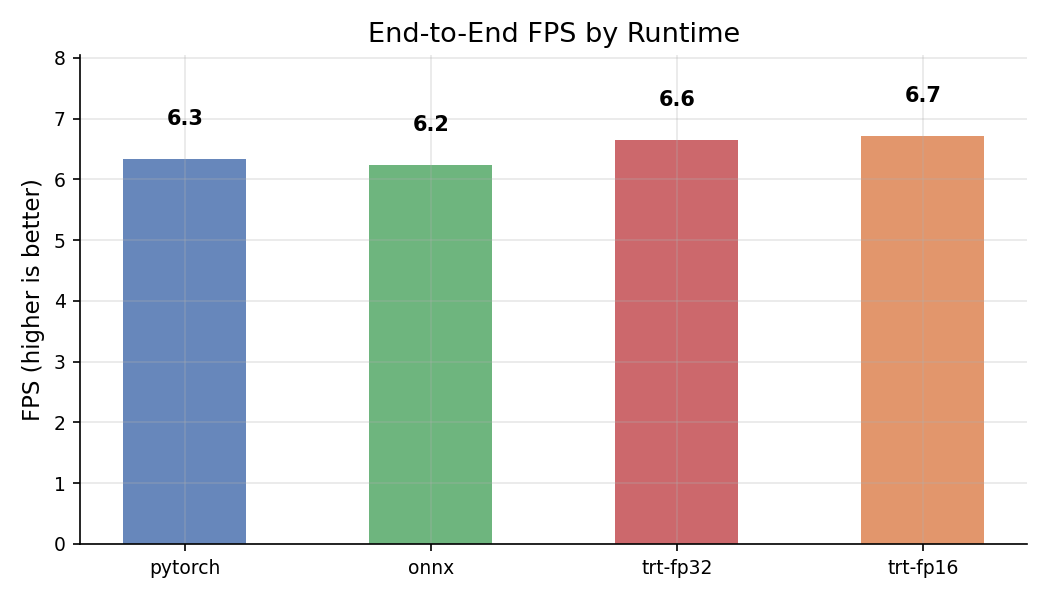

In [28]:
from IPython.display import Image, display

for chart in ['pipeline_breakdown', 'latency_percentiles', 'fps_comparison']:
    print(f'── {chart} ──')
    display(Image(filename=f'plots/{chart}.png'))

### Phase 4 — Download Results

In [29]:
from google.colab import files

for f in ['results/trt_fp32_raw_timings.csv', 'results/trt_fp32_benchmark.csv',
          'results/trt_fp16_raw_timings.csv', 'results/trt_fp16_benchmark.csv']:
    files.download(f)

for chart in ['pipeline_breakdown', 'latency_percentiles', 'fps_comparison']:
    files.download(f'plots/{chart}.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Phase 5 — Pipeline Bottleneck Optimization

Two targeted sweeps based on Phase 2 profiling findings:

**Optimization 1 — Resolution sweep (PyTorch)**
Tests 320×320, 480×480, 640×640 inputs. Quantifies the speed vs detection
quality tradeoff — no model rebuild needed, letterbox handles any size.

**Optimization 2 — Confidence threshold sweep (TRT FP16)**
Tests conf ∈ {0.05, 0.15, 0.25, 0.50, 0.75} on the best runtime. Higher
thresholds pre-filter more boxes before NMS, reducing postprocessing time
at the cost of potentially fewer detections.

Outputs:
- `results/resolution_sweep.csv`   +  `plots/resolution_sweep.png`
- `results/conf_sweep.csv`         +  `plots/conf_sweep.png`

### Phase 5 — Optimization 1: Resolution Sweep (PyTorch)

In [30]:
!python3 scripts/optimize_resolution.py \
    --video       data/clip.mp4 \
    --model       yolo11n.pt \
    --resolutions 320 480 640 \
    --conf        0.25 \
    --iou         0.45 \
    --warmup      10 \
    --results     results/resolution_sweep.csv \
    --plot        plots/resolution_sweep.png \
    --device      cuda

Warming up at 640×640 (10 iters) ...

── 320×320 ────────────────────────────────────────
  FPS=40.9  inf=20.2ms  pre=2.2ms  dets=1.9

── 480×480 ────────────────────────────────────────
  FPS=38.2  inf=20.0ms  pre=3.8ms  dets=3.8

── 640×640 ────────────────────────────────────────
  FPS=33.5  inf=21.0ms  pre=6.3ms  dets=5.0

Res         FPS   inf_ms   pre_ms   post_ms   dets
──────────────────────────────────────────────
320        40.9    20.23     2.19      2.01    1.9
480        38.2    20.03     3.79      2.33    3.8
640        33.5    21.04     6.34      2.51    5.0

Saved → results/resolution_sweep.csv
Saved → plots/resolution_sweep.png


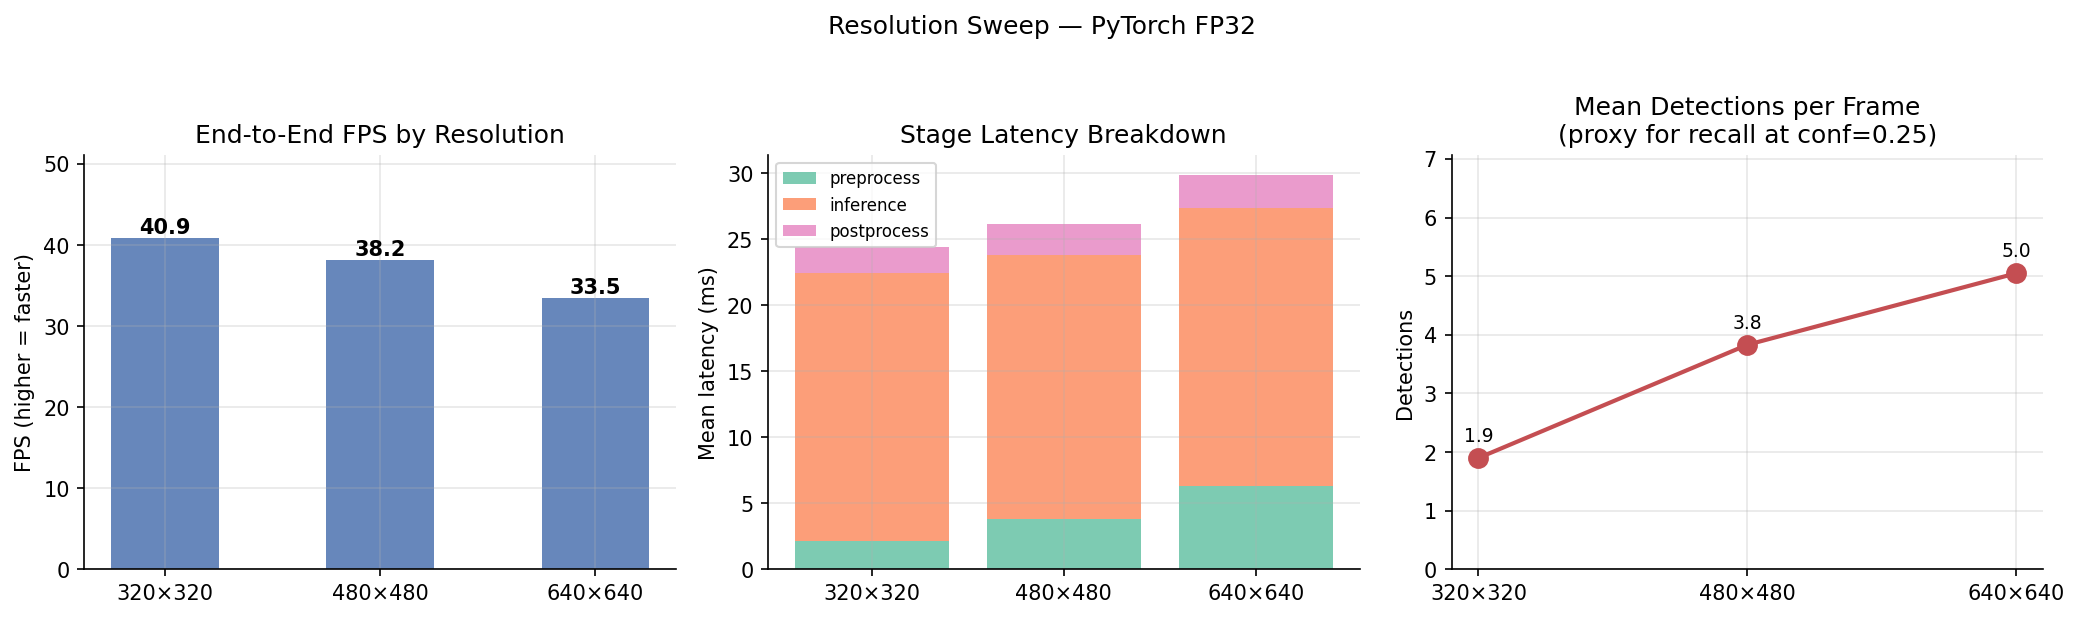

In [31]:
from IPython.display import Image, display
display(Image(filename='plots/resolution_sweep.png'))

### Phase 5 — Optimization 2: Confidence Threshold Sweep (TRT FP16)

In [32]:
!python3 scripts/optimize_conf_threshold.py \
    --video       data/clip.mp4 \
    --engine      models/yolo11n_fp16.engine \
    --conf-values 0.05 0.15 0.25 0.50 0.75 \
    --iou         0.45 \
    --warmup      10 \
    --input-size  640 \
    --results     results/conf_sweep.csv \
    --plot        plots/conf_sweep.png

Loading TRT FP16 engine: models/yolo11n_fp16.engine
GPU: Tesla T4

Warming up (10 iters) ...
[06/24/2026-23:02:53] [TRT] [W] Using default stream in enqueueV3() may lead to performance issues due to additional calls to cudaStreamSynchronize() by TensorRT to ensure correct synchronization. Please use non-default stream instead.

── conf=0.05 ───────────────────────────────────────
  FPS=86.4  post=2.95ms  dets=12.3

── conf=0.15 ───────────────────────────────────────
  FPS=87.2  post=2.80ms  dets=6.8

── conf=0.25 ───────────────────────────────────────
  FPS=87.8  post=2.74ms  dets=5.0

── conf=0.5 ───────────────────────────────────────
  FPS=89.8  post=2.53ms  dets=2.4

── conf=0.75 ───────────────────────────────────────
  FPS=100.7  post=1.27ms  dets=0.3

Conf      FPS   post_ms   dets
──────────────────────────────
0.05     86.4      2.95   12.3
0.15     87.2      2.80    6.8
0.25     87.8      2.74    5.0 ← baseline
0.5      89.8      2.53    2.4
0.75    100.7      1.27    0.3



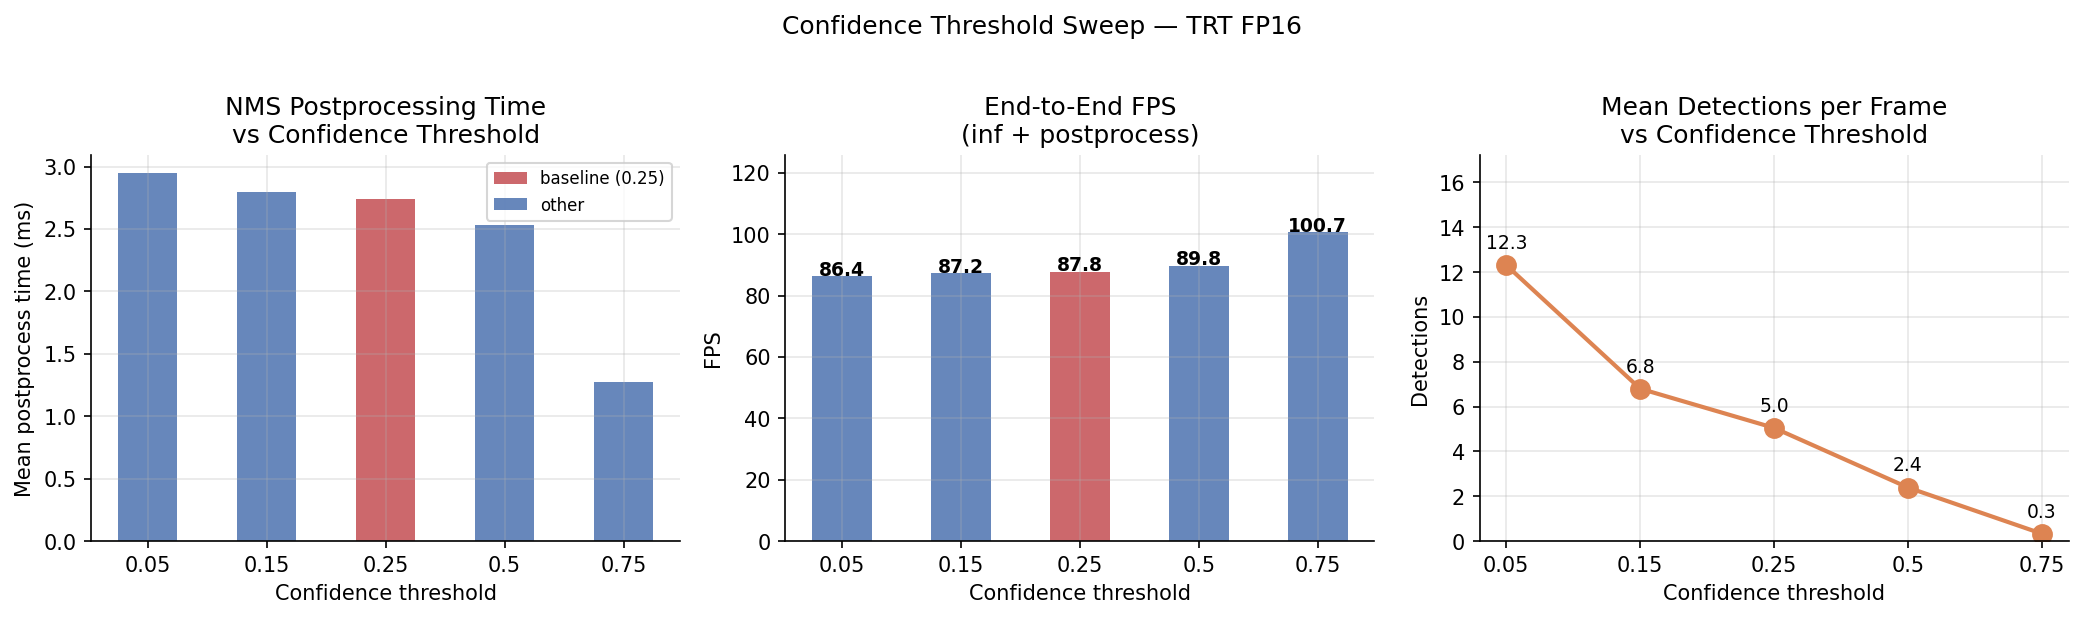

In [33]:
from IPython.display import Image, display
display(Image(filename='plots/conf_sweep.png'))

### Phase 5 — Download Results

In [34]:
from google.colab import files

files.download('results/resolution_sweep.csv')
files.download('results/conf_sweep.csv')
files.download('plots/resolution_sweep.png')
files.download('plots/conf_sweep.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>